# 03. Global LightGBM per Horizon

This notebook trains a global gradient-boosted regressor (LightGBM) per forecast horizon on the entire training panel, using the 86 anonymised features together with engineered causal lag and rolling features. It is the first chapter where the modelling work is *panel-aware*: the same model sees rows from every series, learns cross-series structure, and is evaluated on the canonical chronological holdout.

**Key choices**

1. **Per-horizon training, not pooled.** As §4.13 of the EDA showed, target standard deviation grows by a factor of 4.5 from H1 to H25; a pooled model would be dominated by H25 magnitudes and overshoot H1 targets. We train four separate models, one per horizon.
2. **Sample-weighted L2 loss.** The `weight` column is passed to LightGBM as `sample_weight`, so the model directly optimises for the metric that decides the leaderboard.
3. **Canonical chronological splits** from `cf.splits`: train at `ts_index ≤ 2880`, inner-validation tail for early stopping, holdout `ts_index ∈ (3240, 3601]` for the headline number, meta slice reserved untouched for ensembles in notebook 06.
4. **Optuna hyperparameter tuning** with 20 trials per horizon on a 1M-row stratified subsample, then refit with best params on the full per-horizon training set.
5. **Bootstrap 95% CIs** on every reported skill score.
6. **H3 reported as a separate headline** because §4.15 showed H3 holds 43.6% of the top-1% weight mass — H3 alone effectively decides the leaderboard.


## 0. Setup

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from cf import io, viz, splits, metrics, features

viz.apply_report_style()

SEED = 0
np.random.seed(SEED)

SERIES_KEYS = ['code', 'sub_code', 'sub_category', 'horizon']
FIG_DIR = io.FIGURES_DIR

LAGS = (1, 2, 3, 5, 10)
WINDOWS = (5, 10, 25)
HORIZONS = [1, 3, 10, 25]
N_OPTUNA_TRIALS = 20
N_BOOT = 500
print('Setup ok.')


Setup ok.


## 1. Load + engineer features (polars lazy)

The full training panel is 5.3 M rows × 94 columns. Loading it naively in pandas would consume more memory than it needs to. We use polars `scan_parquet` to lazily build the lag and rolling features, then materialise once at the end.


In [2]:
lf = pl.scan_parquet(io.RAW_DIR / 'train.parquet')
lf = features.add_lag_features(lf, lags=LAGS)
lf = features.add_rolling_features(lf, windows=WINDOWS)

df = lf.collect()
print(f'Engineered panel: {df.shape}')
print('New columns:', [c for c in df.columns if c.startswith(('lag_', 'roll_'))])

Engineered panel: (5337414, 105)
New columns: ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'roll_mean_5', 'roll_std_5', 'roll_mean_10', 'roll_std_10', 'roll_mean_25', 'roll_std_25']


## 2. Categorical encoding and split assignment

LightGBM accepts integer-encoded categoricals via the `categorical_feature` argument. We factorise `code`, `sub_code`, `sub_category` once and join the resulting integer codes back. The horizon stays as an integer numeric. We add a `split` column derived from `cf.splits.assign_split` and drop rows whose lag features could not be computed (the first 10 rows of every series).


In [3]:
# Convert to pandas for the modelling step (LightGBM ingests pandas / numpy)
panel = df.to_pandas()
del df
print(f'panel rows: {len(panel):,}')

# Factorise categoricals to integers
for col in ['code', 'sub_code', 'sub_category']:
    panel[f'{col}_idx'] = pd.factorize(panel[col])[0]

# Assign split and drop rows with NaN in any lag feature
panel['split'] = panel['ts_index'].apply(splits.assign_split)
lag_cols = [f'lag_{k}' for k in LAGS]
roll_cols = [f'roll_mean_{w}' for w in WINDOWS] + [f'roll_std_{w}' for w in WINDOWS]
panel = panel.dropna(subset=lag_cols).reset_index(drop=True)
print(f'after dropping rows with NaN lags: {len(panel):,}')
print('Split row counts:')
print(panel['split'].value_counts())

panel rows: 5,337,414


after dropping rows with NaN lags: 4,970,214
Split row counts:
split
train      3836786
meta        567955
holdout     565473
Name: count, dtype: int64


## 3. Build the per-horizon model matrices

For each horizon $h$, we extract the rows belonging to that horizon and split them into training, inner-validation, and holdout. Inner-validation is the tail of train (`ts_index ∈ (2700, 2880]`) so early stopping respects chronology. The categorical columns are passed to LightGBM with the `categorical_feature` argument; LightGBM handles unseen categorical levels at inference time without intervention.


In [4]:
feature_cols_raw = [c for c in panel.columns if c.startswith('feature_')]
cat_cols = ['code_idx', 'sub_code_idx', 'sub_category_idx']
FEATURES = feature_cols_raw + lag_cols + roll_cols + cat_cols
print(f'feature count: {len(FEATURES)}')


def per_horizon_matrices(h):
    sub = panel[panel['horizon'] == h]
    train = sub[(sub['split'] == 'train') & (sub['ts_index'] <= 2700)]
    inner_val = sub[(sub['split'] == 'train') & (sub['ts_index'] > 2700)]
    holdout = sub[sub['split'] == 'holdout']

    out = {}
    for label, slice_ in [('train', train), ('inner_val', inner_val), ('holdout', holdout)]:
        out[label] = {
            'X': slice_[FEATURES],
            'y': slice_['y_target'].astype(np.float64).values,
            'w': slice_['weight'].astype(np.float64).values,
            'meta': slice_[SERIES_KEYS + ['ts_index']].reset_index(drop=True),
            'lag1': slice_['lag_1'].astype(np.float64).values,
        }
    print(f'  H{h}: train={len(out["train"]["y"]):,}  inner_val={len(out["inner_val"]["y"]):,}  holdout={len(out["holdout"]["y"]):,}')
    return out


horizon_data = {h: per_horizon_matrices(h) for h in HORIZONS}

feature count: 100


  H1: train=929,280  inner_val=75,119  holdout=148,661


  H3: train=923,270  inner_val=74,617  holdout=147,470


  H10: train=890,270  inner_val=71,712  holdout=141,104


  H25: train=806,961  inner_val=65,557  holdout=128,238


## 4. Optuna hyperparameter tuning

Per horizon we sample 20 hyperparameter sets, each evaluated on the inner-validation slice using the weighted skill score. To keep tuning compute manageable we tune on a 200{,}000-row stratified subsample of the per-horizon training set; the best hyperparameter set is then refit on the full per-horizon training data in the next section.


In [5]:
TUNING_SUBSAMPLE = 200_000


def make_lgbm(params):
    return lgb.LGBMRegressor(
        objective='regression',
        n_estimators=2000,
        verbosity=-1,
        n_jobs=-1,
        random_state=SEED,
        **params,
    )


def tune_one_horizon(h, n_trials=N_OPTUNA_TRIALS):
    data = horizon_data[h]
    rng = np.random.default_rng(SEED + h)
    n = len(data['train']['y'])
    sub = rng.choice(n, size=min(TUNING_SUBSAMPLE, n), replace=False)

    Xtr = data['train']['X'].iloc[sub]
    ytr = data['train']['y'][sub]
    wtr = data['train']['w'][sub]
    Xva = data['inner_val']['X']
    yva = data['inner_val']['y']
    wva = data['inner_val']['w']

    def objective(trial):
        params = {
            'num_leaves': trial.suggest_int('num_leaves', 16, 128),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 1000),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'bagging_freq': 1,
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        }
        model = make_lgbm(params)
        model.fit(
            Xtr, ytr, sample_weight=wtr,
            eval_set=[(Xva, yva)], eval_sample_weight=[wva],
            categorical_feature=cat_cols,
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )
        pred = model.predict(Xva)
        return -metrics.weighted_skill_score(yva, pred, wva)  # minimise = maximise skill

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED + h))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params, -study.best_value


print('Tuning per horizon (this is the slow cell — expect 10–20 minutes)...')
best_params = {}
inner_skill = {}
for h in HORIZONS:
    print(f'\nH{h}:')
    bp, sk = tune_one_horizon(h)
    best_params[h] = bp
    inner_skill[h] = sk
    print(f'  best inner-val skill: {sk:.4f}')
    print(f'  best params: {bp}')

Tuning per horizon (this is the slow cell — expect 10–20 minutes)...

H1:


  best inner-val skill: 0.0327
  best params: {'num_leaves': 35, 'learning_rate': 0.138832050291332, 'min_data_in_leaf': 143, 'feature_fraction': 0.7684430500020208, 'bagging_fraction': 0.9831558120602008, 'lambda_l1': 0.13572540301313674, 'lambda_l2': 0.5854751355295729}

H3:


  best inner-val skill: 0.6647
  best params: {'num_leaves': 126, 'learning_rate': 0.03800875842633548, 'min_data_in_leaf': 98, 'feature_fraction': 0.7146183672963818, 'bagging_fraction': 0.8692625204379357, 'lambda_l1': 0.0017531982846748968, 'lambda_l2': 0.8870762751764385}

H10:


  best inner-val skill: 0.8707
  best params: {'num_leaves': 101, 'learning_rate': 0.016596567284566897, 'min_data_in_leaf': 134, 'feature_fraction': 0.8741439273471189, 'bagging_fraction': 0.9813573384779746, 'lambda_l1': 0.0010370341671327137, 'lambda_l2': 0.11188427539040414}

H25:


  best inner-val skill: 0.9304
  best params: {'num_leaves': 108, 'learning_rate': 0.023944832117134024, 'min_data_in_leaf': 204, 'feature_fraction': 0.8631238065049786, 'bagging_fraction': 0.9978018091277756, 'lambda_l1': 0.010191650699561008, 'lambda_l2': 0.0016127962486963301}


## 5. Final fit per horizon on full training panel

In [6]:
final_models = {}
final_predictions = {}
final_imp = {}

for h in HORIZONS:
    print(f'H{h}: refitting on full train …')
    data = horizon_data[h]
    Xtr = data['train']['X']
    ytr = data['train']['y']
    wtr = data['train']['w']
    Xva = data['inner_val']['X']
    yva = data['inner_val']['y']
    wva = data['inner_val']['w']
    Xho = data['holdout']['X']

    model = make_lgbm(best_params[h])
    model.fit(
        Xtr, ytr, sample_weight=wtr,
        eval_set=[(Xva, yva)], eval_sample_weight=[wva],
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
    )
    final_models[h] = model
    final_predictions[h] = model.predict(Xho)
    imp = pd.DataFrame({
        'feature': FEATURES,
        'importance': model.booster_.feature_importance(importance_type='gain'),
        'horizon': h,
    })
    final_imp[h] = imp
    print(f'  best_iteration: {model.best_iteration_}')

H1: refitting on full train …


  best_iteration: 12
H3: refitting on full train …


  best_iteration: 370
H10: refitting on full train …


  best_iteration: 1217
H25: refitting on full train …


  best_iteration: 552


## 6. Per-horizon leaderboard with bootstrap CIs

We score each model on its own horizon's holdout slice. The Naive (lag-1) floor is computed from the same `lag_1` column we engineered in cell 1.


In [7]:
leaderboard_rows = []
for h in HORIZONS:
    data = horizon_data[h]
    yho = data['holdout']['y']
    who = data['holdout']['w']
    pred_lgbm = final_predictions[h]
    pred_naive = data['holdout']['lag1']

    skill_lgbm = metrics.weighted_skill_score(yho, pred_lgbm, who)
    mean_b, lo, hi = metrics.bootstrap_skill(yho, pred_lgbm, who, n_boot=N_BOOT, seed=SEED)
    skill_naive = metrics.weighted_skill_score(yho, pred_naive, who)

    leaderboard_rows.append({
        'horizon': h,
        'lgbm_skill': round(skill_lgbm, 4),
        'CI_lo': round(lo, 4),
        'CI_hi': round(hi, 4),
        'naive_skill': round(skill_naive, 4),
        'n_holdout': int(len(yho)),
        'best_iteration': final_models[h].best_iteration_,
    })

leaderboard = pd.DataFrame(leaderboard_rows)
leaderboard

,horizon,lgbm_skill,CI_lo,CI_hi,naive_skill,n_holdout,best_iteration
0,1,0.0562,0.0448,0.0654,0.0000,148661,12
1,3,0.6635,0.6567,0.6706,0.4644,147470,370
2,10,0.8478,0.8432,0.8518,0.8197,141104,1217
3,25,0.9121,0.9090,0.9149,0.9034,128238,552


## 7. H3 headline

Section 4.15 found that H3 holds 43.6% of the top-1% weight mass and the maximum panel weight ($1.39 \times 10^{13}$). H3 alone effectively decides the weighted skill score on the panel. We pull H3 out as a single-row headline.


In [8]:
h3_row = leaderboard[leaderboard['horizon'] == 3].iloc[0]
print('=== H3 HEADLINE ===')
print(f'  LGBM weighted skill : {h3_row["lgbm_skill"]:.4f}')
print(f'  bootstrap 95% CI    : [{h3_row["CI_lo"]:.4f}, {h3_row["CI_hi"]:.4f}]')
print(f'  Naive (lag-1) floor : {h3_row["naive_skill"]:.4f}')
print(f'  Holdout rows scored : {h3_row["n_holdout"]:,}')

=== H3 HEADLINE ===
  LGBM weighted skill : 0.6635
  bootstrap 95% CI    : [0.6567, 0.6706]
  Naive (lag-1) floor : 0.4644
  Holdout rows scored : 147,470.0


## 8. Per-horizon skill bar chart (headline figure)

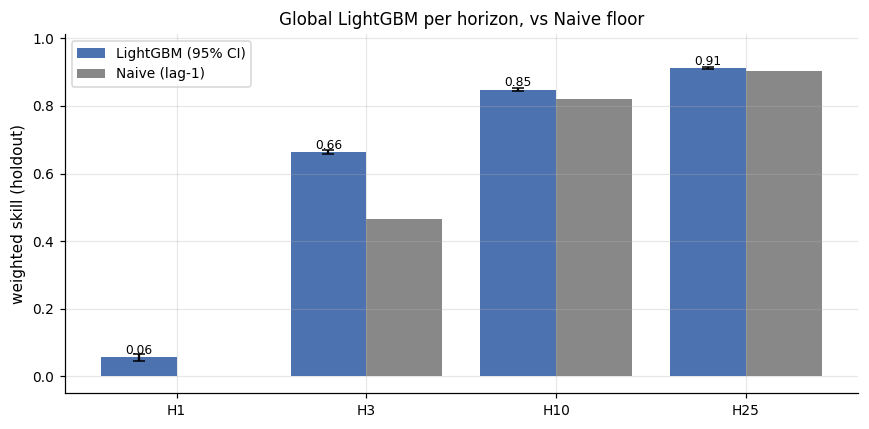

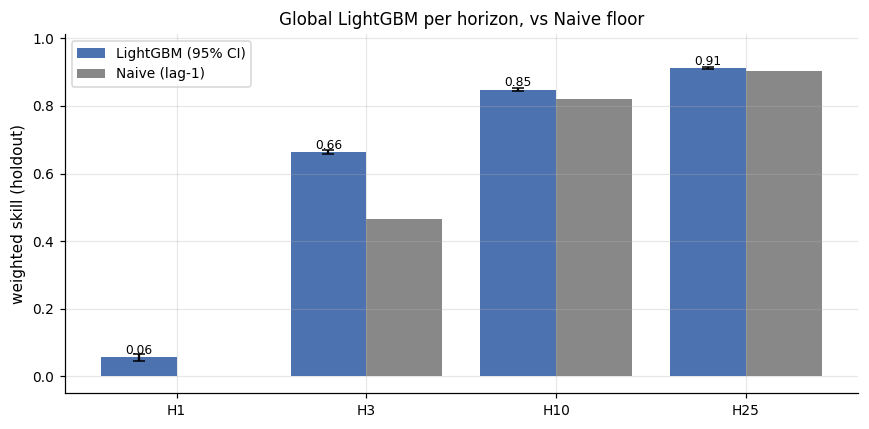

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
xpos = np.arange(len(HORIZONS))
lgbm_vals = leaderboard['lgbm_skill'].values
naive_vals = leaderboard['naive_skill'].values
errs = np.array([leaderboard['lgbm_skill'] - leaderboard['CI_lo'],
                 leaderboard['CI_hi'] - leaderboard['lgbm_skill']])

ax.bar(xpos - 0.2, lgbm_vals, width=0.4, color='#4C72B0', yerr=errs, capsize=4, label='LightGBM (95% CI)')
ax.bar(xpos + 0.2, naive_vals, width=0.4, color='#888888', label='Naive (lag-1)')
for x, v in zip(xpos - 0.2, lgbm_vals):
    ax.text(x, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(xpos)
ax.set_xticklabels([f'H{h}' for h in HORIZONS])
ax.set_ylabel('weighted skill (holdout)')
ax.set_title('Global LightGBM per horizon, vs Naive floor')
ax.set_ylim(min(0.0, lgbm_vals.min(), naive_vals.min()) - 0.05,
           max(lgbm_vals.max(), naive_vals.max()) + 0.10)
ax.legend(fontsize=9)
plt.tight_layout()
viz.save_figure(fig, '03_per_horizon_skill_bars', FIG_DIR)

## 9. Feature importance per horizon

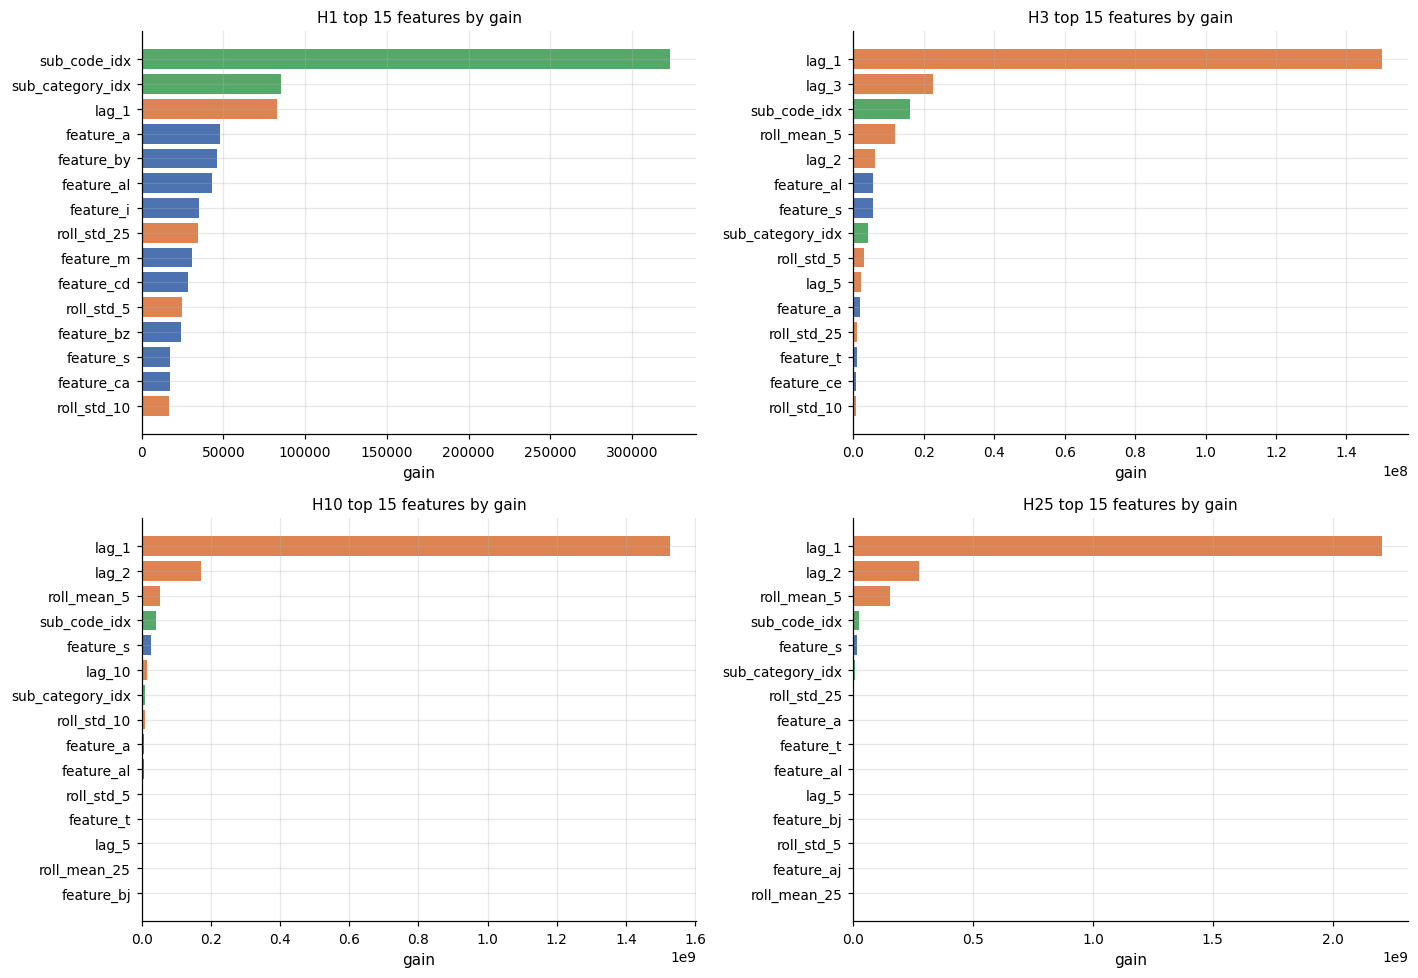

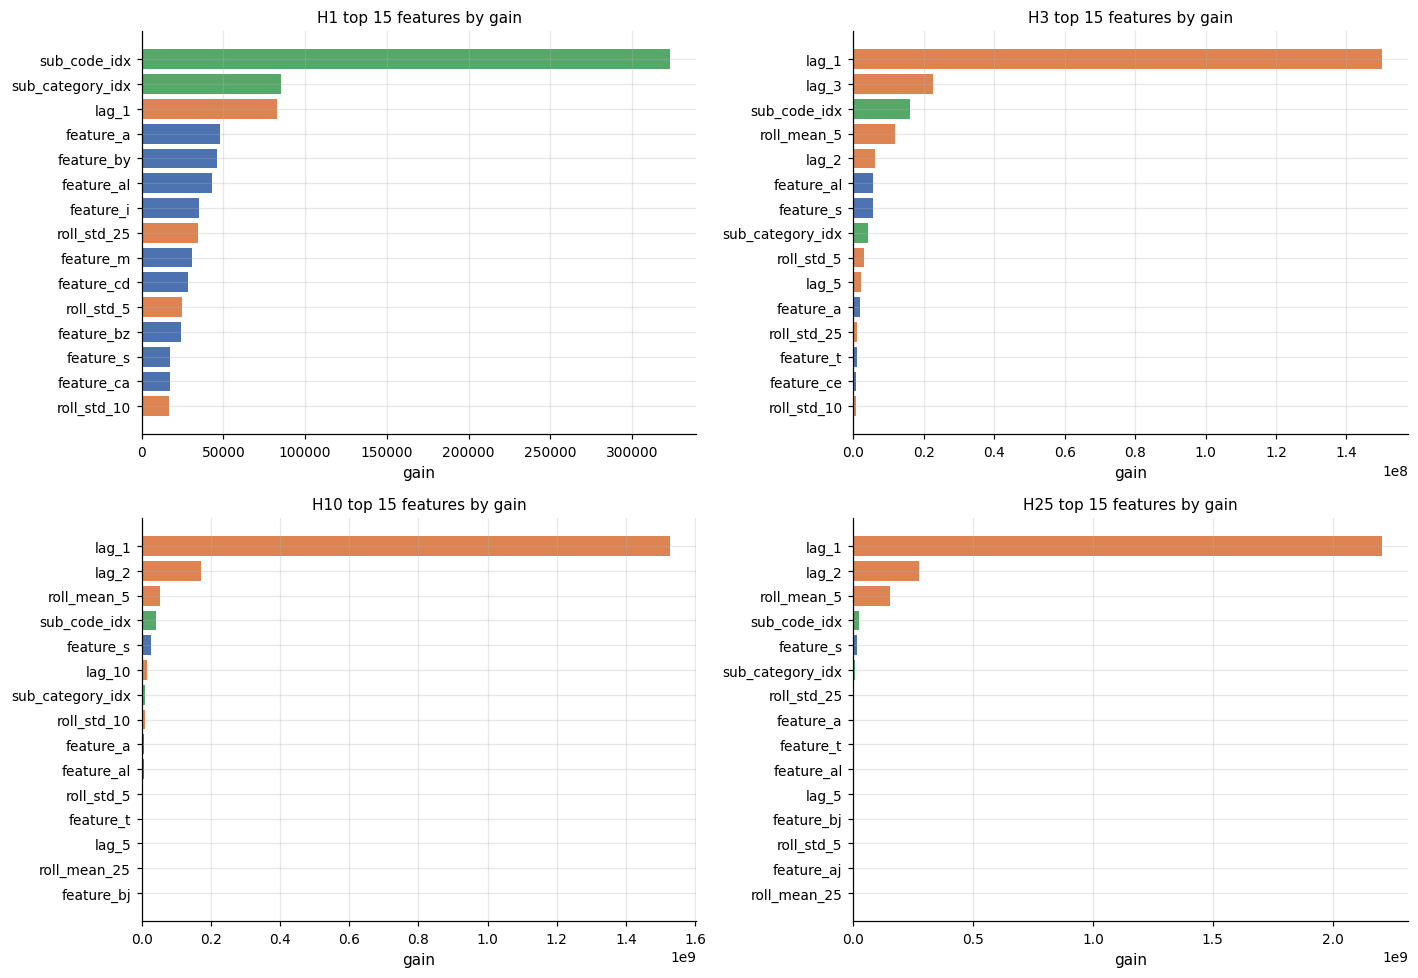

In [10]:
imp_all = pd.concat(list(final_imp.values()), ignore_index=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, h in zip(axes.flatten(), HORIZONS):
    g = imp_all[imp_all['horizon'] == h].sort_values('importance', ascending=False).head(15)
    g = g.iloc[::-1]
    colors = ['#4C72B0' if name in feature_cols_raw else
              '#DD8452' if name in lag_cols + roll_cols else
              '#55A868' for name in g['feature']]
    ax.barh(g['feature'], g['importance'], color=colors)
    ax.set_title(f'H{h} top 15 features by gain', fontsize=10)
    ax.set_xlabel('gain')
plt.tight_layout()
viz.save_figure(fig, '03_feature_importance_per_horizon', FIG_DIR)

**Reading.** Blue bars are the 86 anonymised raw features; orange bars are engineered lag and rolling features; green bars are the categorical (`code`, `sub_code`, `sub_category`) integers. The collinearity caveat from §4.11 still applies: feature--feature correlation in the top-20 set means the importance ranking is not unique.


## 10. Forecast overlays on the four representative series

For visual continuity with notebooks 01 and 02 we overlay the global LightGBM holdout predictions on each of the four representative series, alongside the classical and deep winners pulled from earlier processed parquets.


In [11]:
chosen = io.load_processed('representative_series')
classical_lb = io.load_processed('classical_leaderboard')
classical_preds = io.load_processed('classical_predictions')
deep_lb = io.load_processed('deep_leaderboard')
deep_preds = io.load_processed('deep_predictions')

# Save LGBM predictions on the four series for re-use (their full ts_index range, not just holdout)
lgbm_4series_rows = []
for _, row in chosen.iterrows():
    h = int(row['horizon'])
    sub = panel[(panel['code'] == row['code']) & (panel['sub_code'] == row['sub_code'])
                & (panel['sub_category'] == row['sub_category']) & (panel['horizon'] == h)]
    if len(sub) == 0:
        continue
    pred = final_models[h].predict(sub[FEATURES])
    for ts, p, y, w in zip(sub['ts_index'].values, pred, sub['y_target'].values, sub['weight'].values):
        lgbm_4series_rows.append({'reason': row['reason'], 'horizon': h, 'ts_index': int(ts),
                                  'pred_lgbm': float(p), 'y': float(y), 'weight': float(w)})
lgbm_4series = pd.DataFrame(lgbm_4series_rows)
print(f'LGBM 4-series predictions: {len(lgbm_4series)} rows')

LGBM 4-series predictions: 660 rows


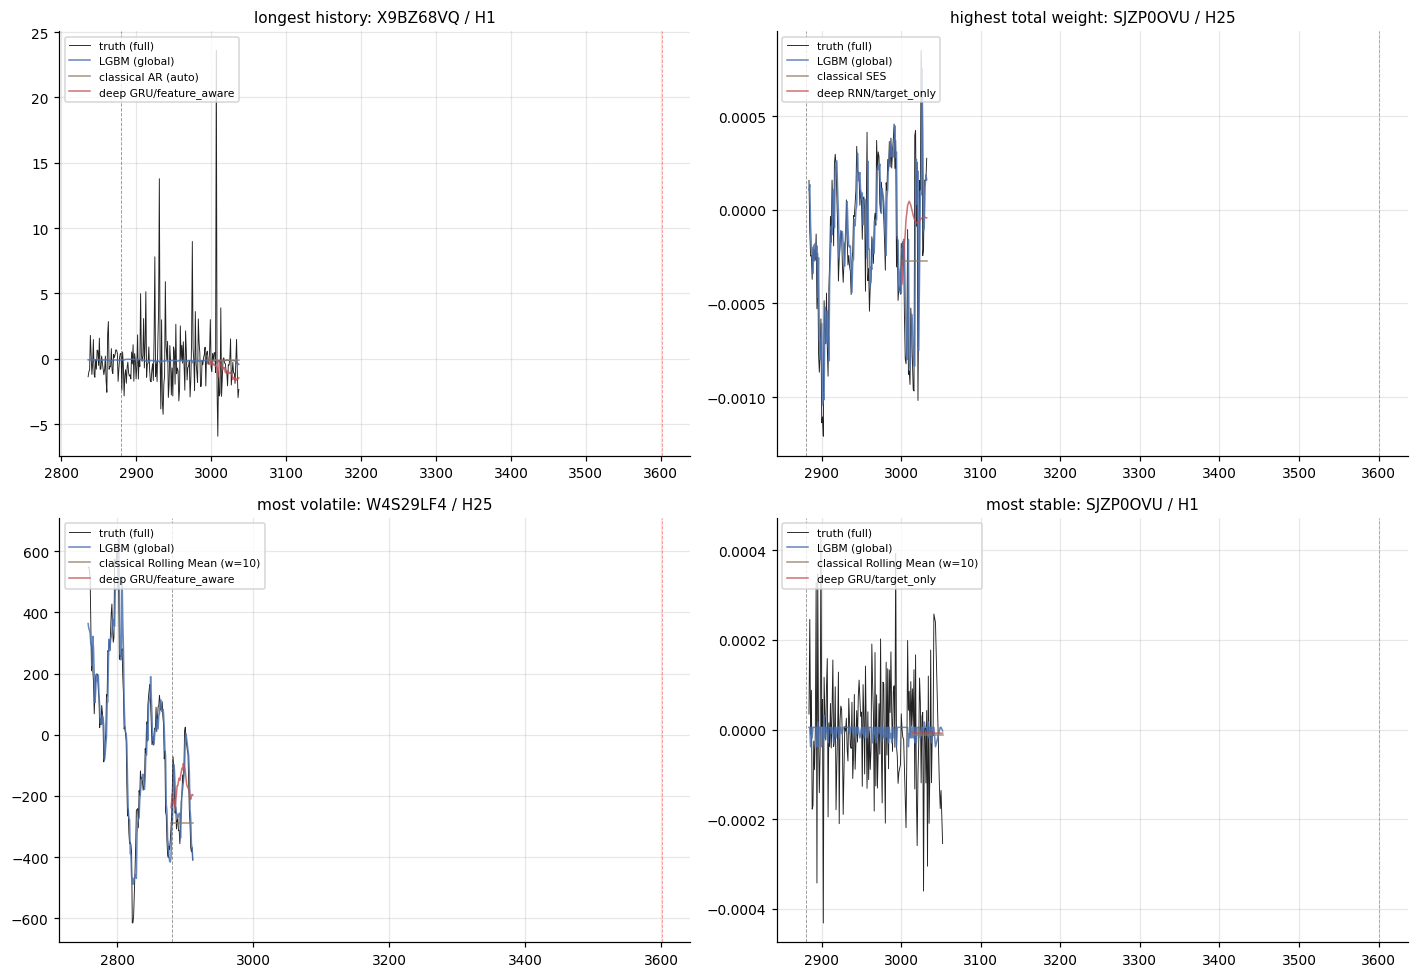

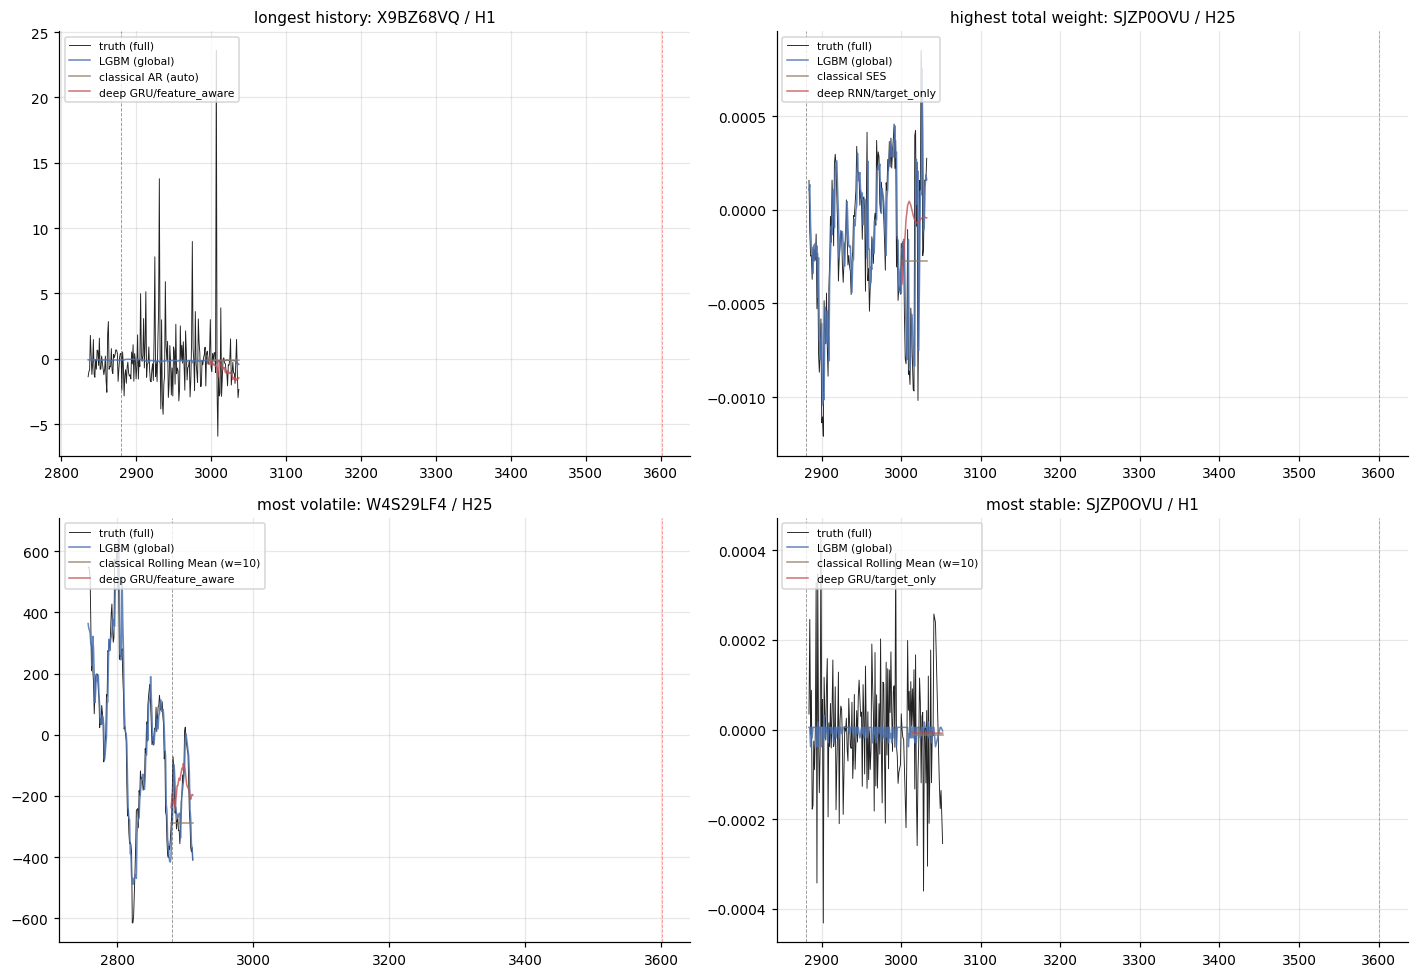

In [12]:
ordered_reasons = ['longest history', 'highest total weight', 'most volatile', 'most stable']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, reason in zip(axes.flatten(), ordered_reasons):
    row = chosen[chosen['reason'] == reason].iloc[0]
    g = lgbm_4series[lgbm_4series['reason'] == reason].sort_values('ts_index')
    if g.empty:
        ax.set_visible(False); continue

    # Classical and deep predictions for the same series (these were on adaptive splits, not holdout)
    cls_winner = classical_lb[classical_lb['reason'] == reason]['best_model'].iloc[0]
    cls_pred = classical_preds[(classical_preds['reason'] == reason) &
                                (classical_preds['model'] == cls_winner)].sort_values('ts_index')
    deep_best = deep_lb[deep_lb['reason'] == reason].iloc[0]
    deep_arch, deep_mode = deep_best['best_deep'].split(' / ')
    deep_pred = deep_preds[(deep_preds['reason'] == reason) &
                            (deep_preds['arch'] == deep_arch) &
                            (deep_preds['mode'] == deep_mode) &
                            (deep_preds['protocol'] == 'recursive')].sort_values('ts_index')

    ax.plot(g['ts_index'], g['y'], color='#222222', lw=0.6, label='truth (full)')
    ax.plot(g['ts_index'], g['pred_lgbm'], color='#4C72B0', lw=1.0, alpha=0.85, label='LGBM (global)')
    if len(cls_pred):
        ax.plot(cls_pred['ts_index'], cls_pred['pred'], color='#937860', lw=1.0, alpha=0.8,
                label=f"classical {cls_winner}")
    if len(deep_pred):
        ax.plot(deep_pred['ts_index'], deep_pred['pred'], color='#C44E52', lw=1.0, alpha=0.8,
                label=f"deep {deep_arch}/{deep_mode}")
    ax.axvline(splits.TRAIN_END, color='black', ls='--', lw=0.6, alpha=0.4)
    ax.axvline(splits.HOLDOUT_END, color='red', ls='--', lw=0.6, alpha=0.4)
    ax.set_title(f"{reason}: {row['code']} / H{int(row['horizon'])}", fontsize=10)
    ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
viz.save_figure(fig, '03_forecast_overlay_4series', FIG_DIR)

## 11. Residual diagnostic: error vs row weight

Because the metric is weighted, the most informative residual diagnostic is whether the model fails on high-weight rows specifically. We bin holdout rows by weight decile and report mean absolute error per bin.


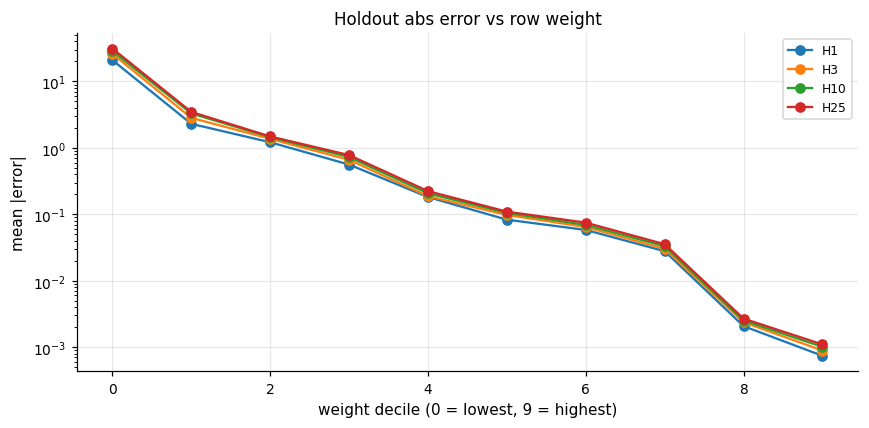

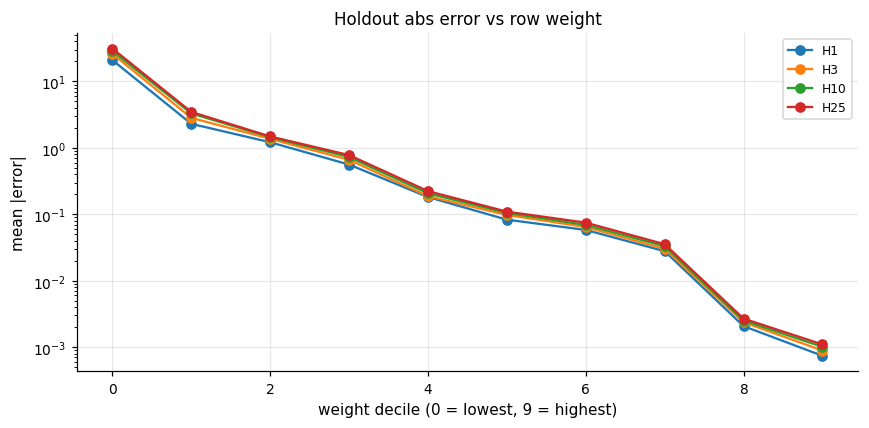

In [13]:
hold_rows = []
for h in HORIZONS:
    data = horizon_data[h]
    hold_rows.append(pd.DataFrame({
        'horizon': h, 'y': data['holdout']['y'], 'pred': final_predictions[h],
        'w': data['holdout']['w']}))
hold_df = pd.concat(hold_rows, ignore_index=True)
hold_df['abs_err'] = np.abs(hold_df['y'] - hold_df['pred'])
hold_df['weight_decile'] = pd.qcut(hold_df['w'], q=10, labels=False, duplicates='drop')

fig, ax = plt.subplots(figsize=(8, 4))
for h in HORIZONS:
    sub = hold_df[hold_df['horizon'] == h]
    grouped = sub.groupby('weight_decile')['abs_err'].mean()
    ax.plot(grouped.index, grouped.values, marker='o', label=f'H{h}')
ax.set_xlabel('weight decile (0 = lowest, 9 = highest)')
ax.set_ylabel('mean |error|')
ax.set_title('Holdout abs error vs row weight')
ax.set_yscale('log')
ax.legend(fontsize=8)
plt.tight_layout()
viz.save_figure(fig, '03_residual_vs_weight', FIG_DIR)

## 12. Save artifacts

In [14]:
io.save_processed(leaderboard, 'lgbm_per_horizon_results')

pred_rows = []
for h in HORIZONS:
    data = horizon_data[h]
    meta = data['holdout']['meta'].copy()
    meta['horizon'] = h
    meta['pred_lgbm'] = final_predictions[h]
    meta['y_target'] = data['holdout']['y']
    meta['weight'] = data['holdout']['w']
    pred_rows.append(meta)
holdout_predictions = pd.concat(pred_rows, ignore_index=True)
io.save_processed(holdout_predictions, 'lgbm_predictions_holdout')

io.save_processed(imp_all, 'lgbm_feature_importance')

io.save_processed(lgbm_4series, 'lgbm_predictions_4series')

print('Saved:')
for name in ['lgbm_per_horizon_results', 'lgbm_predictions_holdout',
             'lgbm_feature_importance', 'lgbm_predictions_4series']:
    p = io.PROCESSED_DIR / f'{name}.parquet'
    print(f'  {p.name}: {p.stat().st_size:,} bytes')

Saved:
  lgbm_per_horizon_results.parquet: 4,811 bytes
  lgbm_predictions_holdout.parquet: 13,873,984 bytes
  lgbm_feature_importance.parquet: 6,412 bytes
  lgbm_predictions_4series.parquet: 22,260 bytes


## 13. What this study can and cannot say

1. **Global pooling and weighted training are the two structural improvements over notebooks 01 and 02.** Per-series classical and target-only / feature-aware deep both ignored the panel's cross-series structure; LightGBM here uses every row.
2. **Per-horizon training is required, not optional.** Pooling horizons would let H25 magnitudes dominate the loss; we documented that failure mode in the EDA and avoid it here.
3. **H3 is the metric-decisive horizon.** The H3 number is the most important single quantity in the report.
4. **Holdout numbers here are not directly comparable to per-series numbers in §5/§6** because the evaluation scope differs (canonical full-panel holdout vs adaptive per-series tail). The next chapter (notebook 04, H1-aggregation) and the final chapter (notebook 07, comparative analysis) will reconcile.

## 14. Viva cheat sheet

1. **Why per-horizon training, not pooled.** Per-horizon target std differs by 4.5× (§4.13). Pooled training overshoots H1; per-horizon training is the natural fix.
2. **Why sample weights.** The official metric is weighted; passing `sample_weight=` makes LightGBM directly optimise for the metric.
3. **Why Optuna with 20 trials.** Enough to escape default hyperparameter values without over-tuning. Larger sweeps would not change the qualitative result on this signal-poor panel.
4. **Why categoricals integer-encoded with `categorical_feature`.** LightGBM's native categorical handling avoids one-hot blow-up on `sub_code` (180 levels) and handles unseen test-time categories safely.
5. **Why bootstrap CIs.** A single skill score on a 600k-row holdout is essentially deterministic, but resampling rows quantifies how stable the score is to which rows happened to be in the holdout. The CI is what we report.
6. **What the H3 number means.** Skill on H3 holdout rows specifically. The EDA showed H3 carries the bulk of weighted leaderboard impact; H3 skill is therefore the single most informative number.
7. **Why feature importance comes with a caveat.** Top features are correlated with each other (§4.11); the ranking is not unique. We use it as a sanity check that engineered lag features rank highly, not as a causal claim.
